## Podstawowe metody przetwarzania obrazu
Ten kod to fragment programu w Pythonie przygotowujący środowisko do przetwarzania i wizualizacji obrazów — szczególnie z użyciem biblioteki scikit-image (skimage), NumPy, i matplotlib.

Co robi ten kod:

* Importuje narzędzia do pracy z obrazami.

* Ustawia domyślne parametry wykresu.

* Definiuje funkcję show_row(), która pozwala łatwo wyświetlać wiele obrazów w jednym wierszu.

* pokazuje przykład użycia tej funkcji.

In [1]:
# ============================================
# Import potrzebnych bibliotek
# ============================================
import numpy as np                          # NumPy – obsługa tablic i obliczeń numerycznych
import matplotlib.pyplot as plt              # Matplotlib – do rysowania i wyświetlania obrazów
from skimage import io, color, exposure, filters, util, morphology
# skimage.io          – wczytywanie/zapisywanie obrazów
# skimage.color       – konwersja przestrzeni barw (np. RGB → grayscale)
# skimage.exposure    – regulacja jasności, kontrastu, histogramów itp.
# skimage.filters     – filtry obrazu (np. rozmycie, wykrywanie krawędzi)
# skimage.util        – operacje pomocnicze (np. dodawanie szumu)
# skimage.morphology  – operacje morfologiczne (np. erozja, dylatacja)
from skimage.metrics import structural_similarity as ssim
# skimage.metrics.ssim – metryka podobieństwa strukturalnego (ocena podobieństwa obrazów)

# ============================================
# Ustawienia wykresów
# ============================================
plt.rcParams["figure.figsize"] = (12, 4)     # Domyślny rozmiar rysunku: szerokość 12 cali, wysokość 4 cale

# ============================================
# Funkcja pomocnicza do wyświetlania obrazów w jednym wierszu
# ============================================
def show_row(images, titles=None, cmap=None):
    """
    Wyświetla kilka obrazów obok siebie w jednym wierszu.

    Parametry:
    -----------
    images : list
        Lista obrazów (tablic NumPy) do wyświetlenia.
    titles : list (opcjonalnie)
        Lista tytułów dla każdego obrazu.
    cmap : str (opcjonalnie)
        Mapa kolorów (np. 'gray' dla obrazów w skali szarości).
    """

    n = len(images)                          # Liczba obrazów
    fig, axes = plt.subplots(1, n)           # Tworzy jeden wiersz z n kolumnami (dla każdego obrazu jedna oś)

    # Iteracja po wszystkich obrazach i ich osiach
    for i, ax in enumerate(np.atleast_1d(axes)):
        ax.imshow(images[i], cmap=cmap)      # Wyświetla obraz (z opcjonalną mapą kolorów)
        ax.axis('off')                       # Ukrywa osie (ramki, skale, liczby)
        if titles:                           # Jeśli podano tytuły
            ax.set_title(titles[i])          # Ustawia tytuł nad obrazem

    plt.show()                               # Wyświetla całość

# ============================================
# Przykład użycia (opcjonalnie)
# ============================================
# from skimage import data
# img = data.astronaut()                     # Wczytanie przykładowego obrazu
# gray = color.rgb2gray(img)                 # Konwersja na skalę szarości
# blur = filters.gaussian(gray, sigma=2)     # Rozmycie obrazu filtrem Gaussa
#
# # Wyświetlenie trzech obrazów obok siebie
# show_row([img, gray, blur],
#           titles=["Oryginał", "Skala szarości", "Rozmyty"],
#           cmap='gray')


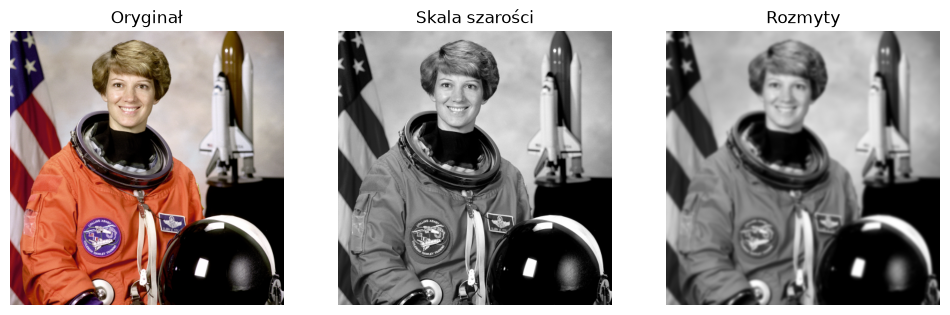

In [4]:
from skimage import data
img = data.astronaut()
gray = color.rgb2gray(img)
blur = filters.gaussian(gray, sigma=2)

show_row([img, gray, blur], titles=["Oryginał", "Skala szarości", "Rozmyty"], cmap='gray')

# Wczytanie + kanały + histogram

Co robi ten kod:
* Wczytuje obraz

* Rozdziela obraz na kanały R, G, B.

* Wyświetla oryginał i każdy kanał osobno.

* Konwertuje obraz do skali szarości.

* Rysuje histogram jasności – pokazujący rozkład tonalny obrazu.

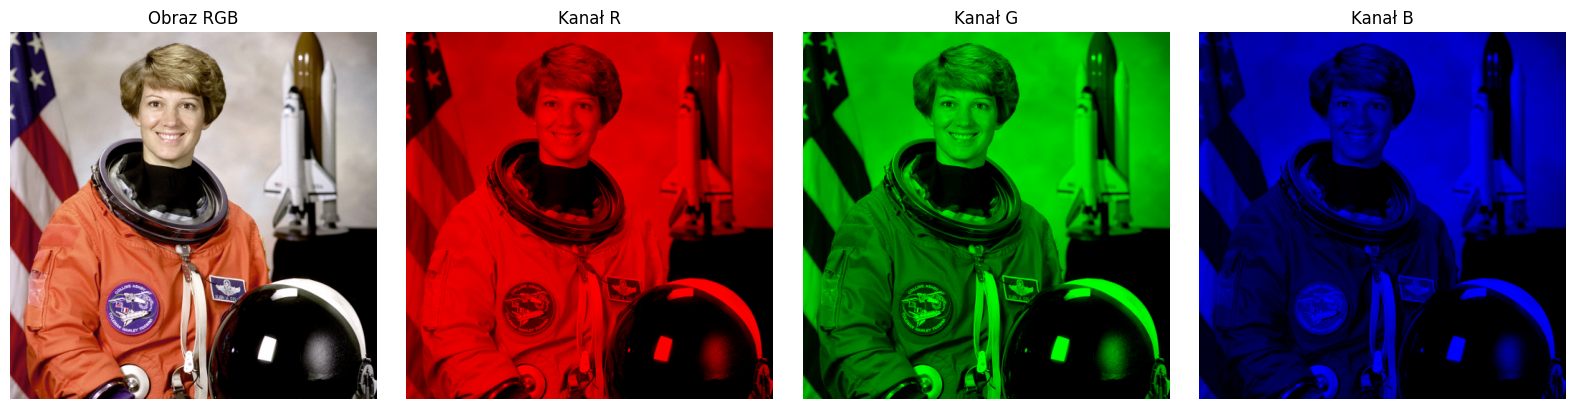

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data

# ============================================================
# Wczytanie obrazu
# ============================================================

# Wczytanie przykładowego obrazu "astronaut" z biblioteki skimage
img_rgb = data.astronaut()

# ============================================================
# Podgląd RGB i kanałów R / G / B
# ============================================================

# Tworzymy trzy kopie obrazu.
# W każdej z nich pozostawiamy tylko jeden wybrany kanał,
# a wartości pozostałych kanałów ustawiamy na 0.

# Kanał czerwony
red = np.zeros_like(img_rgb)
red[:, :, 0] = img_rgb[:, :, 0]

# Kanał zielony
green = np.zeros_like(img_rgb)
green[:, :, 1] = img_rgb[:, :, 1]

# Kanał niebieski
blue = np.zeros_like(img_rgb)
blue[:, :, 2] = img_rgb[:, :, 2]

# Wyświetlenie obrazu RGB oraz poszczególnych kanałów
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(img_rgb)
axes[0].set_title("Obraz RGB")
axes[0].axis("off")

axes[1].imshow(red)
axes[1].set_title("Kanał R")
axes[1].axis("off")

axes[2].imshow(green)
axes[2].set_title("Kanał G")
axes[2].axis("off")

axes[3].imshow(blue)
axes[3].set_title("Kanał B")
axes[3].axis("off")

plt.tight_layout()
plt.show()

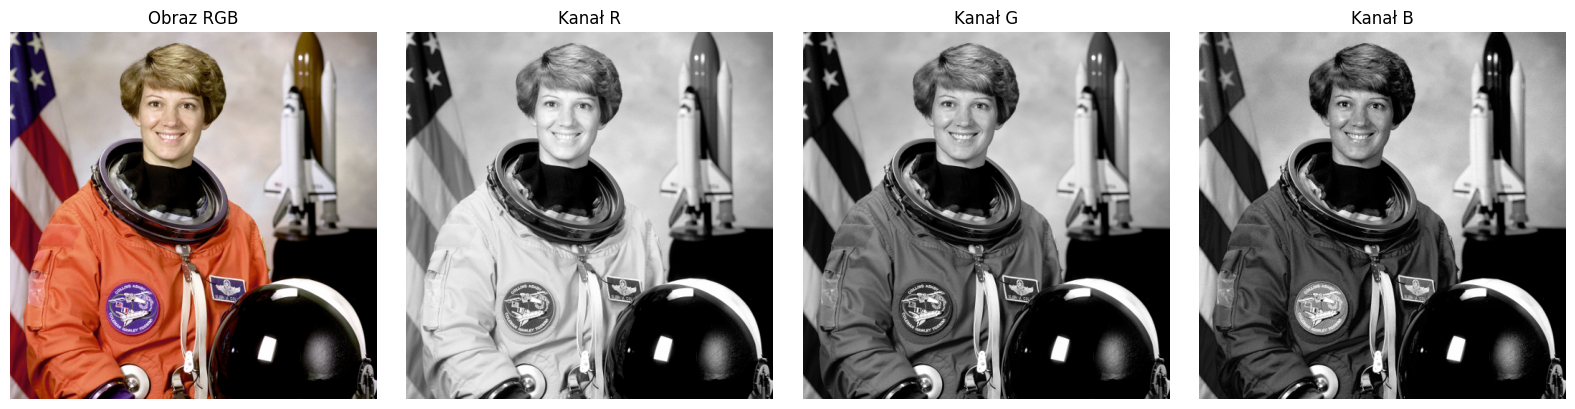

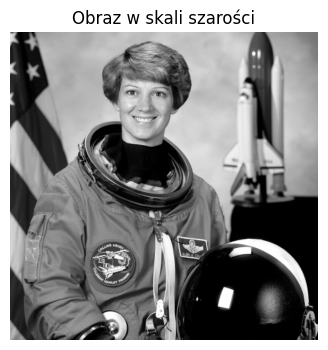

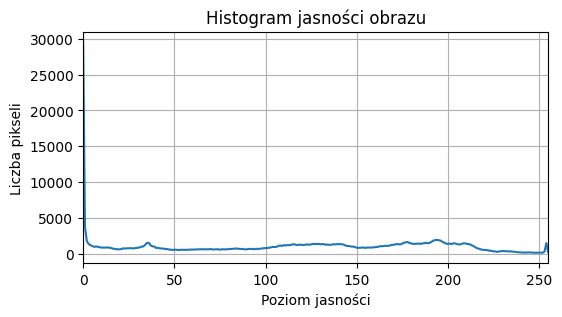

In [ ]:
# Wczytanie obrazu i analiza kanałów kolorów

import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color

# Wczytuję obraz z biblioteki skimage - astronauta
img = data.astronaut()

# Jeśli obraz jest w skali szarości -> powiel kanał 3 razy,
# aby uzyskać pseudo-RGB.
# Jeśli obraz ma kanał alfa (RGBA) -> usuń go, zostawiając tylko R, G, B.
if img.ndim == 2:
    img_rgb = np.stack([img, img, img], axis=-1)
elif img.shape[2] == 4:
    img_rgb = img[:, :, :3]
else:
    img_rgb = img

# ============================================================
# Podgląd RGB i kanałów R / G / B
# ============================================================

# Wyodrębnienie poszczególnych kanałów koloru z obrazu RGB.
# img_rgb[:, :, 0] -> kanał czerwony (Red)
# img_rgb[:, :, 1] -> kanał zielony (Green)
# img_rgb[:, :, 2] -> kanał niebieski (Blue)

# Wyświetlenie oryginalnego obrazu RGB oraz trzech kanałów R, G, B obok siebie.
# Kanały są pokazane w skali szarości, aby uwidocznić ich intensywność- wtedy jasność oznacza siłę danego kanału.
#Na przykład w kanale R jasne miejsca mają dużo czerwieni, a ciemne — mało czerwieni. Analogicznie dla G i B.
#Dlatego np. pomarańczowy kombinezon jest bardzo jasny w kanale R, słabszy w G i dużo ciemniejszy w B.
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(img_rgb)
axes[0].set_title("Obraz RGB")
axes[0].axis("off")

axes[1].imshow(img_rgb[:, :, 0], cmap="gray")
axes[1].set_title("Kanał R")
axes[1].axis("off")

axes[2].imshow(img_rgb[:, :, 1], cmap="gray")
axes[2].set_title("Kanał G")
axes[2].axis("off")

axes[3].imshow(img_rgb[:, :, 2], cmap="gray")
axes[3].set_title("Kanał B")
axes[3].axis("off")

plt.tight_layout()
plt.show()

# ============================================================
# Wyświetlenie obrazu w skali szarości
# ============================================================

# cmap="gray" informuje matplotlib, że obraz ma być
# wyświetlany przy użyciu odcieni szarości.
plt.figure(figsize=(4, 4))

plt.imshow(gray, cmap="gray")

plt.title("Obraz w skali szarości")
plt.axis("off")

plt.show()


# ============================================================
# Histogram jasności obrazu
# ============================================================

# Konwersja z RGB do skali szarości – wykorzystuje ważoną percepcyjnie luminancję
# w zakresie 0–1.
gray = color.rgb2gray(img_rgb)

# Przeliczamy wartości jasności z zakresu 0–1 na zakres 0–255
# i konwertujemy je na typ uint8.
gray_8bit = (gray * 255).astype(np.uint8)

# Rysowanie histogramu rozkładu jasności pikseli.
# np.histogram() oblicza liczbę pikseli należących do każdego poziomu jasności.
# bins=256 -> przedziały jasności 0–255.
hist, bins = np.histogram(
    gray_8bit.flatten(),
    bins=256,
    range=(0, 256)
)

# Wyświetlenie histogramu. Histogramem jasności całego obrazu po konwersji RGB → skala szarości.
plt.figure(figsize=(6, 3))
plt.plot(hist)

plt.title("Histogram jasności obrazu")
plt.xlabel("Poziom jasności")
plt.ylabel("Liczba pikseli")

plt.xlim([0, 255])
plt.grid()

plt.show()

# Reprezentacja poziomów jasności obrazu: zakres 0–255 i 0–1
W cyfrowym przetwarzaniu obrazów wartości pikseli mogą być zapisywane w różnych zakresach liczbowych. Najczęściej spotykane są dwa sposoby reprezentacji:

**0–255** oraz **0–1**.

Oba zakresy mogą opisywać dokładnie tę samą informację o jasności piksela. Różni się jedynie sposób zapisu wartości.

---
## Obraz zapisany w zakresie 0–255

Typowym sposobem przechowywania obrazów jest zapis 8-bitowy (`uint8`).

Każdy piksel może wtedy przyjmować jedną z 256 wartości:

- `0` – kolor czarny,
- `255` – kolor biały,

Liczba **256 poziomów jasności** wynika z zastosowania 8 bitów:

\[
2^8 = 256
\]

---

## Obraz zapisany w zakresie 0–1

W wielu bibliotekach do przetwarzania obrazów, w tym w `scikit-image`, podczas wykonywania operacji matematycznych często stosuje się obrazy typu `float`.

Wtedy wartości pikseli są zazwyczaj zapisane w zakresie:

\[
0.0 \leq I \leq 1.0
\]

gdzie:

- `0.0` – kolor czarny,
- `1.0` – kolor biały,
---
## Przeliczanie między zakresami

Aby przeliczyć wartość z zakresu 0–255 na zakres 0–1, można zastosować:

wartosc_float = wartosc_uint8 / 255

I odwrotnie:

wartosc_uint8 = wartosc_float * 255

Zmiana zakresu nie oznacza zmiany informacji zawartej w obrazie. Jest to jedynie inny sposób reprezentacji wartości.

---

# Normalizacja, Wyrównanie histogramu





# Normalizacja histogramu (ang. histogram normalization lub contrast stretching)
Normalizacja rozciąga zakres jasności obrazu tak, by wykorzystać cały możliwy przedział — np. od 0 do 1 (dla float) lub od 0 do 255 (dla uint8).

Przykład:

Jeśli obraz ma piksele tylko w zakresie [50, 180], to normalizacja przeskaluje je do [0, 255].
Dzięki temu:
* cienie staną się czarne,
* jasne miejsca – jaśniejsze,
* kontrast wzrośnie liniowo.

# Wyrównanie histogramu (ang. histogram equalization)
Wyrównanie histogramu dąży do bardziej równomiernego wykorzystania dostępnego zakresu poziomów jasności. Histogram wynikowy nie musi być idealnie płaski.
Nie tylko rozciąga, ale też nieliniowo przekształca wartości, tak by różne poziomy jasności były reprezentowane z podobną częstością.

Efekt:
* zwiększa kontrast lokalny,
* uwidacznia szczegóły w ciemnych i jasnych partiach obrazu,
* histogram po operacji staje się „bardziej równy”.

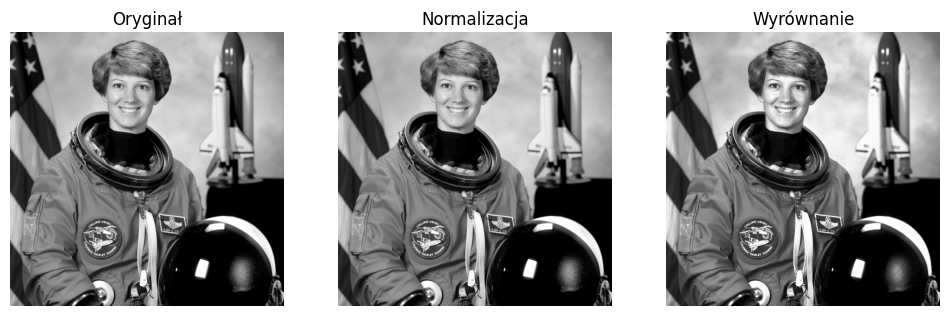

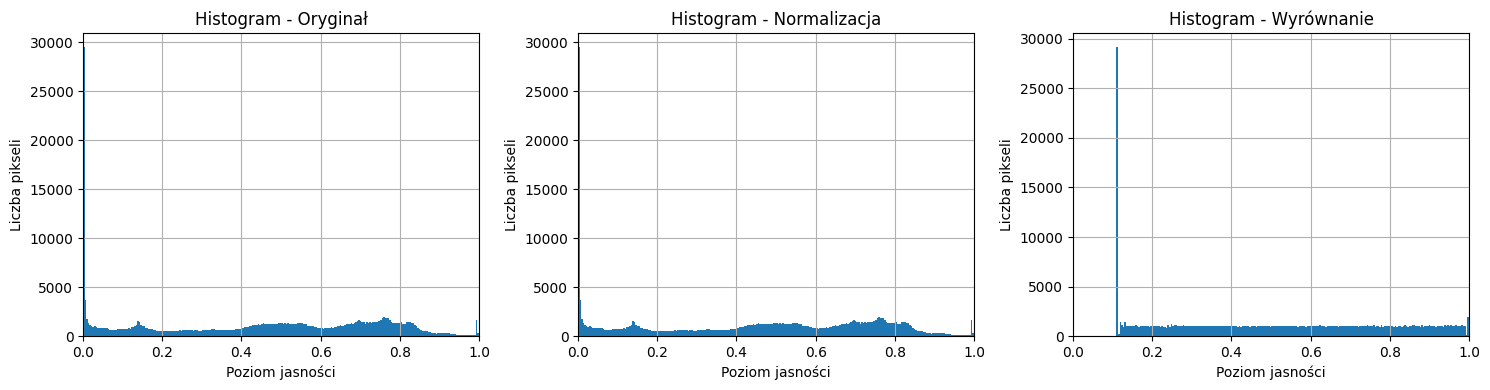

In [ ]:
from skimage import data, color, exposure
import matplotlib.pyplot as plt

# Wczytanie obrazu astronauty z wbudowanego zestawu skimage i konwersja do skali szarości
# Funkcja rgb2gray() zamienia obraz RGB na odcienie szarości, co ułatwia analizę jasności.
img = color.rgb2gray(data.astronaut())

# Normalizacja kontrastu
# Funkcja rescale_intensity() rozciąga zakres jasności pikseli tak, by najmniejsza wartość = 0, a największa = 1.
# Dzięki temu obraz lepiej wykorzystuje dostępny zakres intensywności i ma wyraźniejszy kontrast.
norm = exposure.rescale_intensity(img, in_range='image', out_range=(0, 1))

# Wyrównanie histogramu (Histogram Equalization)
# equalize_hist() modyfikuje rozkład intensywności tak, aby histogram był bardziej równomierny.
# To poprawia kontrast, szczególnie w ciemnych i jasnych fragmentach obrazu.
eq = exposure.equalize_hist(img)

# Wizualizacja wyników obok siebie
# Tworzymy 3 wykresy: oryginał, wersję po normalizacji i po wyrównaniu histogramu.
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
titles = ['Oryginał', 'Normalizacja', 'Wyrównanie']

# Wyświetlenie każdego obrazu w skali szarości z odpowiednim tytułem
for ax, im, t in zip(axes, [img, norm, eq], titles):
    ax.imshow(im, cmap='gray')  # Wyświetlenie obrazu w odcieniach szarości
    ax.set_title(t)             # Ustawienie tytułu wykresu
    ax.axis('off')              # Ukrycie osi dla czystszego wyglądu

# Wyświetlenie całej figury
plt.show()


# ============================================================
# Histogramy obrazów
# ============================================================

# Tworzymy 3 wykresy histogramów:
# dla obrazu oryginalnego, po normalizacji i po wyrównaniu histogramu.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histogram obrazu oryginalnego
# ravel() zamienia obraz dwuwymiarowy na jedną tablicę wartości pikseli.
axes[0].hist(img.ravel(), bins=256, range=(0, 1))
axes[0].set_title('Histogram - Oryginał')
axes[0].set_xlabel('Poziom jasności')
axes[0].set_ylabel('Liczba pikseli')
axes[0].set_xlim(0, 1)
axes[0].grid()

# Histogram obrazu po normalizacji
axes[1].hist(norm.ravel(), bins=256, range=(0, 1))
axes[1].set_title('Histogram - Normalizacja')
axes[1].set_xlabel('Poziom jasności')
axes[1].set_ylabel('Liczba pikseli')
axes[1].set_xlim(0, 1)
axes[1].grid()

# Histogram obrazu po wyrównaniu histogramu
axes[2].hist(eq.ravel(), bins=256, range=(0, 1))
axes[2].set_title('Histogram - Wyrównanie')
axes[2].set_xlabel('Poziom jasności')
axes[2].set_ylabel('Liczba pikseli')
axes[2].set_xlim(0, 1)
axes[2].grid()

# Dopasowanie odstępów między wykresami
plt.tight_layout()

# Wyświetlenie histogramów
plt.show()

Wyrównanie histogramu rozciąga i przekształca poziomy jasności, ale jeśli bardzo duża liczba pikseli ma dokładnie tę samą jasność, wszystkie zostaną przekształcone do tej samej nowej wartości. Dlatego w histogramie nadal może pozostać wysoki pik.

podmień: `img = color.rgb2gray(data.astronaut())` na `img = data.moon()`

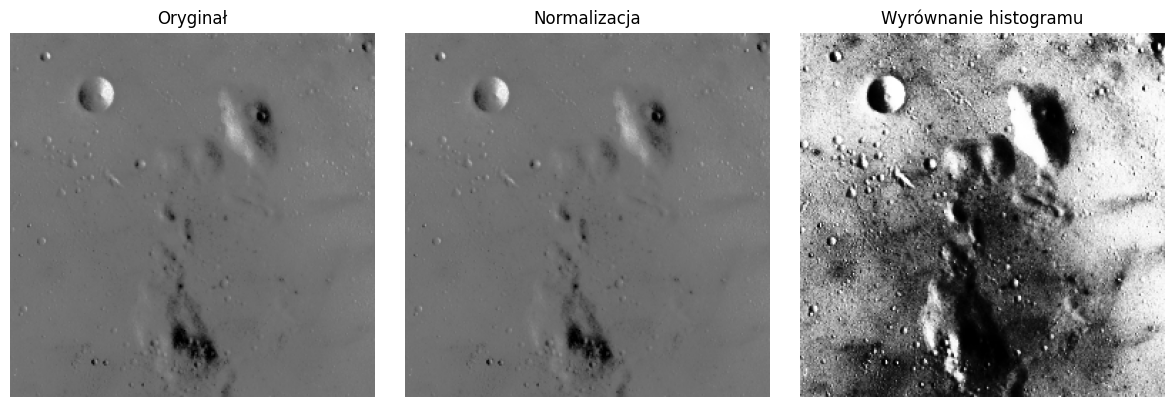

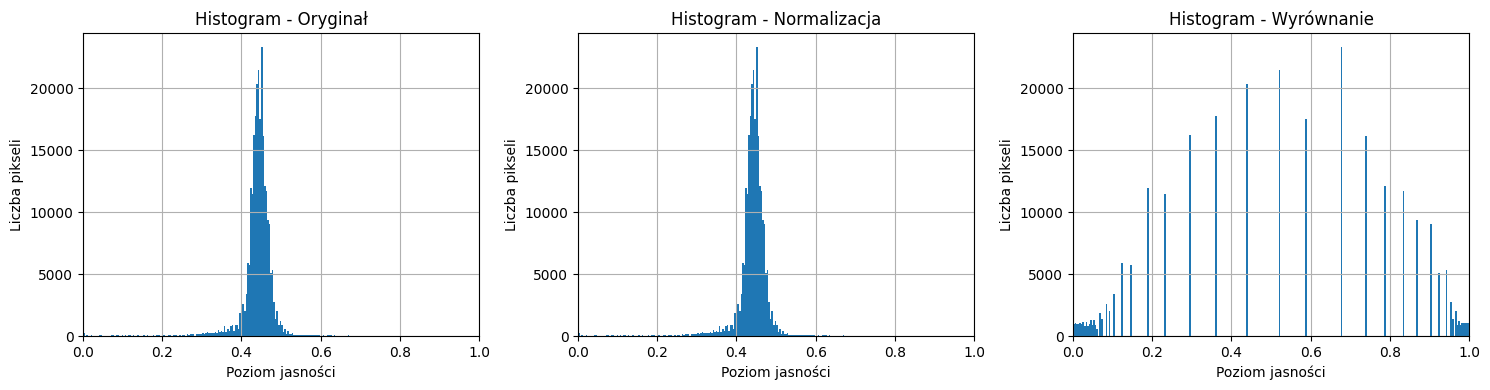

In [ ]:
from skimage import data, exposure, img_as_float
import matplotlib.pyplot as plt

img = img_as_float(data.moon())

norm = exposure.rescale_intensity(
    img,
    in_range='image',
    out_range=(0, 1)
)

eq = exposure.equalize_hist(img)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

titles = [
    'Oryginał',
    'Normalizacja',
    'Wyrównanie histogramu'
]

images = [
    img,
    norm,
    eq
]

for ax, im, t in zip(axes, images, titles):
    ax.imshow(im, cmap='gray', vmin=0, vmax=1)
    ax.set_title(t)
    ax.axis('off')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(img.ravel(), bins=256, range=(0, 1))
axes[0].set_title('Histogram - Oryginał')
axes[0].set_xlabel('Poziom jasności')
axes[0].set_ylabel('Liczba pikseli')
axes[0].set_xlim(0, 1)
axes[0].grid()

axes[1].hist(norm.ravel(), bins=256, range=(0, 1))
axes[1].set_title('Histogram - Normalizacja')
axes[1].set_xlabel('Poziom jasności')
axes[1].set_ylabel('Liczba pikseli')
axes[1].set_xlim(0, 1)
axes[1].grid()

axes[2].hist(eq.ravel(), bins=256, range=(0, 1))
axes[2].set_title('Histogram - Wyrównanie')
axes[2].set_xlabel('Poziom jasności')
axes[2].set_ylabel('Liczba pikseli')
axes[2].set_xlim(0, 1)
axes[2].grid()

plt.tight_layout()
plt.show()

W obrazie moon() są pojedyncze bardzo ciemne i bardzo jasne piksele. One już powodują, że zakres obrazu jest dość szeroki. W efekcie normalizacja nie ma czego spektakularnie „rozciągnąć”.

Normalizacja liniowa nie zawsze musi wizualnie poprawić obraz. Jeśli obraz już wykorzystuje szeroki zakres intensywności, efekt może być niewielki. Wyrównanie histogramu działa inaczej — zmienia rozkład jasności, dlatego jego efekt jest znacznie bardziej widoczny.

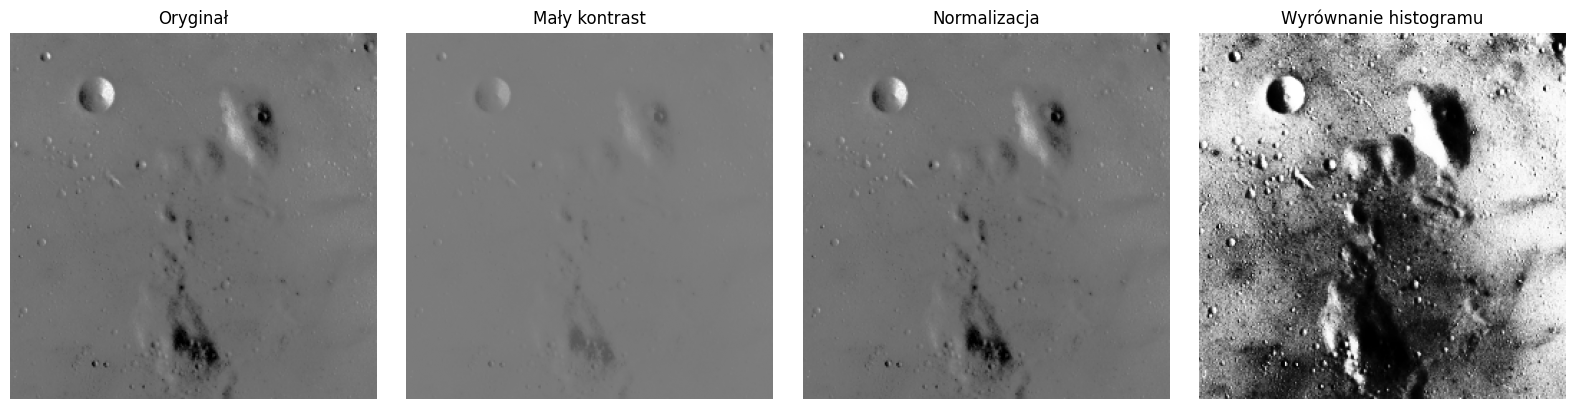

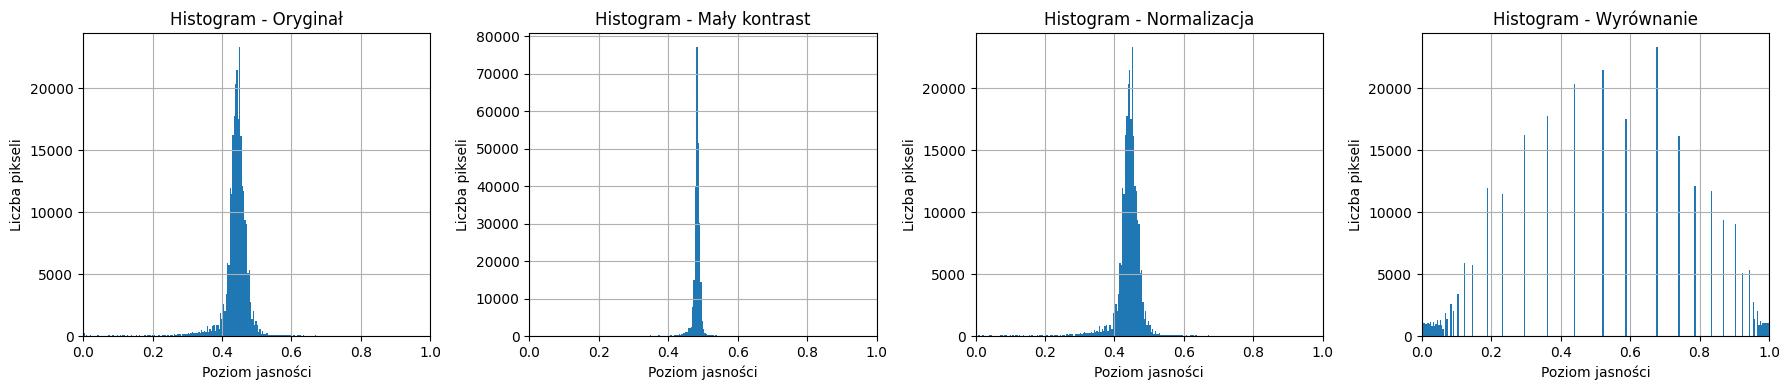

In [ ]:
#Przykład obrazu o słabym kontraście (sztucznie zmniejszonym)
from skimage import data, exposure, img_as_float
import matplotlib.pyplot as plt

# Wczytanie obrazu
img = img_as_float(data.moon())

# Celowe zmniejszenie kontrastu obrazu
low_contrast = exposure.rescale_intensity(
    img,
    in_range=(0, 1),
    out_range=(0.35, 0.65)
)

# Normalizacja obrazu o małym kontraście
norm = exposure.rescale_intensity(
    low_contrast,
    in_range='image',
    out_range=(0, 1)
)

# Wyrównanie histogramu obrazu o małym kontraście
eq = exposure.equalize_hist(low_contrast)


# ============================================================
# Wyświetlenie obrazów
# ============================================================

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

titles = [
    'Oryginał',
    'Mały kontrast',
    'Normalizacja',
    'Wyrównanie histogramu'
]

images = [
    img,
    low_contrast,
    norm,
    eq
]

for ax, im, t in zip(axes, images, titles):
    ax.imshow(im, cmap='gray', vmin=0, vmax=1)
    ax.set_title(t)
    ax.axis('off')

plt.tight_layout()
plt.show()


# ============================================================
# Wyświetlenie histogramów
# ============================================================

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

axes[0].hist(img.ravel(), bins=256, range=(0, 1))
axes[0].set_title('Histogram - Oryginał')
axes[0].set_xlabel('Poziom jasności')
axes[0].set_ylabel('Liczba pikseli')
axes[0].set_xlim(0, 1)
axes[0].grid()

axes[1].hist(low_contrast.ravel(), bins=256, range=(0, 1))
axes[1].set_title('Histogram - Mały kontrast')
axes[1].set_xlabel('Poziom jasności')
axes[1].set_ylabel('Liczba pikseli')
axes[1].set_xlim(0, 1)
axes[1].grid()

axes[2].hist(norm.ravel(), bins=256, range=(0, 1))
axes[2].set_title('Histogram - Normalizacja')
axes[2].set_xlabel('Poziom jasności')
axes[2].set_ylabel('Liczba pikseli')
axes[2].set_xlim(0, 1)
axes[2].grid()

axes[3].hist(eq.ravel(), bins=256, range=(0, 1))
axes[3].set_title('Histogram - Wyrównanie')
axes[3].set_xlabel('Poziom jasności')
axes[3].set_ylabel('Liczba pikseli')
axes[3].set_xlim(0, 1)
axes[3].grid()

plt.tight_layout()
plt.show()

In [ ]:
from skimage import data, exposure, img_as_float
import matplotlib.pyplot as plt

img = img_as_float(data.moon())

low_contrast = exposure.rescale_intensity(
    img,
    in_range=(0, 1),
    out_range=(0.35, 0.65)
)

norm = exposure.rescale_intensity(
    low_contrast,
    in_range='image',
    out_range=(0, 1)
)

# Podstawowe przekształcenia geometryczne obrazu
Przekształcenia geometryczne należą do podstawowych operacji w przetwarzaniu obrazów cyfrowych. Ich celem jest zmiana położenia, orientacji lub rozmiaru elementów obrazu bez modyfikacji jego treści (czyli wartości jasności i kolorów).
Przekształcenia geometryczne zmieniają położenie pikseli lub sposób odwzorowania obrazu w przestrzeni. W przypadku operacji takich jak obrót czy skalowanie może być konieczna interpolacja, która wyznacza nowe wartości pikseli.

Do najczęściej stosowanych przekształceń geometrycznych należą:

* Translacja (przesunięcie) – zmiana położenia obrazu w płaszczyźnie (np.
przesunięcie w prawo lub w dół).
* Rotacja (obrót) – obrót obrazu wokół zadanego punktu, najczęściej środka.
* Skalowanie (reskalowanie) – powiększenie lub pomniejszenie obrazu poprzez zmianę odległości między pikselami.
* Odbicie (symetria lustrzana) – zamiana stron obrazu w poziomie lub pionie.
* Transformacje afiniczne (affine transformations) – ogólniejsze przekształcenia, które obejmują rotację, skalowanie, translację i ścinanie (shear).
* Transformacje perspektywiczne (projective transformations) – bardziej złożone operacje pozwalające odwzorować efekty wynikające ze zmiany punktu widzenia kamery.

Poniżej w kodzie zastosowano przykład przekaszłcenia obrazu:
* Obrót (rotate) – zmienia orientację obrazu o określony kąt.
* Odbicie lustrzane (flip) – odwraca obraz w poziomie.
* Skalowanie (rescale) – zmniejsza lub powiększa obraz.

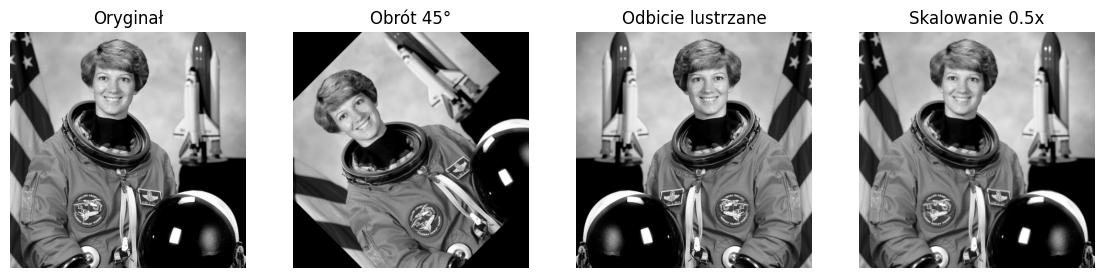

In [ ]:
# Import potrzebnych bibliotek
from skimage import data, color, transform
import matplotlib.pyplot as plt

# Wczytanie przykładowego obrazu i konwersja do skali szarości
# Używamy zdjęcia astronauty, które jest dostępne w skimage.
img = color.rgb2gray(data.astronaut())

# Obrót obrazu o 45 stopni
# transform.rotate() obraca obraz o zadany kąt (w stopniach, przeciwnie do ruchu wskazówek zegara).
rotated = transform.rotate(img, angle=45)

# Odbicie lustrzane w poziomie
# slicing [:, ::-1] odwraca kolejność kolumn (pionowych pikseli), co daje efekt lustrzanego odbicia.
flipped = img[:, ::-1]

# Skalowanie (zmiana rozmiaru)
# transform.rescale() zmienia wielkość obrazu o podany współczynnik (tu 0.5 = zmniejszenie do 50%).
scaled = transform.rescale(img, scale=0.5, anti_aliasing=True)

# Wizualizacja wszystkich przekształceń
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
titles = ['Oryginał', 'Obrót 45°', 'Odbicie lustrzane', 'Skalowanie 0.5x']

# Wyświetlenie każdego obrazu w odcieniach szarości
for ax, im, t in zip(axes, [img, rotated, flipped, scaled], titles):
    ax.imshow(im, cmap='gray')
    ax.set_title(t)
    ax.axis('off')

# Wyświetlenie wyniku
plt.show()

# Konwersja przestrzeni barw

Przestrzeń barw (ang. color space) to sposób matematycznego opisu koloru, który określa, jak kolory są reprezentowane i interpretowane przez komputer.

Różne przestrzenie barw lepiej nadają się do różnych zastosowań w przetwarzaniu obrazów i wizji komputerowej.
Konwersja umożliwia:

* Oddzielenie jasności od koloru. W przestrzeniach takich jak HSV, LAB czy YUV, można analizować jasność (np. „Value”, „L” lub „Y”) osobno od barwy.
To bardzo przydatne przy analizie obrazów, gdy oświetlenie jest nierównomierne.
* Segmentację kolorów
W przestrzeni HSV łatwo odseparować obiekty o określonej barwie, bo „Hue” opisuje odcień w sposób intuicyjny (np. czerwony ≈ 0°, niebieski ≈ 240°).
* Lepsze odwzorowanie percepcji człowieka
W przestrzeni LAB różnice między kolorami są bardziej zgodne z tym, jak widzi je człowiek — przydatne przy porównywaniu obrazów czy ocenie jakości.
* Kompresję i przetwarzanie wideo
Dzięki temu można kompresować dane o barwie bez dużej utraty jakości obrazu — tak działa np. JPEG i MPEG.

Dodatkowe funkcje w skimage.color:

* color.rgb2gray() – RGB → skala szarości
* color.gray2rgb() – grayscale → RGB
* color.hsv2rgb() – HSV → RGB
* color.lab2rgb() – LAB → RGB
* color.yuv2rgb() – YUV → RGB


Analiza kodu poniżej:
* Wczytujemy obraz RGB (np. astronauta ze skimage.data).
* Konwertujemy go kolejno do innych przestrzeni barw:
* rgb2hsv() – użyteczne np. przy segmentacji kolorów.
* rgb2lab() – przestrzeń dopasowana do ludzkiej percepcji kolorów.
* rgb2yuv() – często stosowana w kompresji wideo i obrazów.

Wizualizujemy oryginał i poszczególne kanały każdej przestrzeni:

* w HSV: H (odcień), S (nasycenie), V (jasność),
* w LAB: L (luminancja), a i b (składowe kolorów),
* w YUV: Y (jasność), U i V (informacja o barwie).




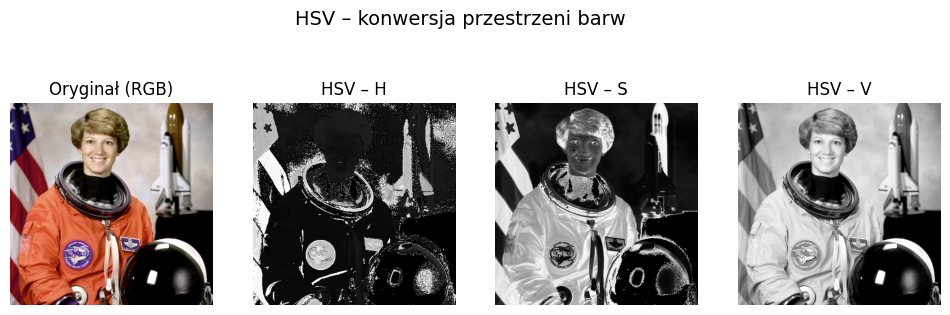

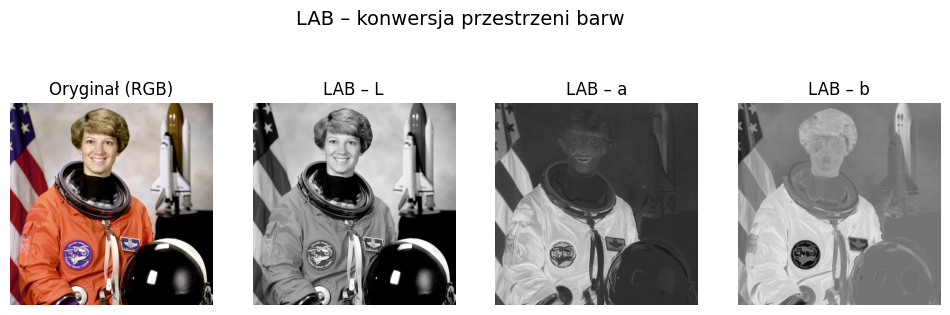

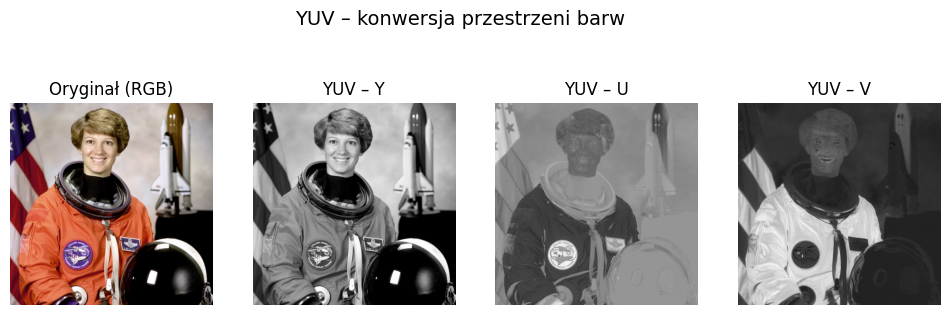

In [ ]:
# ============================================
# Przykład: Zmiana przestrzeni barw w Pythonie (scikit-image)
# ============================================

import matplotlib.pyplot as plt
from skimage import data, color

# Wczytanie przykładowego obrazu z biblioteki skimage
img_rgb = data.astronaut()   # Obraz w formacie RGB (Red, Green, Blue)

# ============================================
# RGB → HSV
# ============================================
# HSV (Hue, Saturation, Value)
# Hue – barwa (0–1)
# Saturation – nasycenie koloru (0–1)
# Value – jasność (0–1)
img_hsv = color.rgb2hsv(img_rgb)

# ============================================
# RGB → LAB
# ============================================
# LAB to przestrzeń, w której:
# L – jasność (Lightness)
# a – składowa koloru od zielonego do czerwonego
# b – składowa koloru od niebieskiego do żółtego
img_lab = color.rgb2lab(img_rgb)

# ============================================
# RGB → YUV
# ============================================
# YUV (lub YCbCr) rozdziela luminancję (Y) od chrominancji (U,V).
# Często używana w telewizji i kompresji wideo (np. w JPEG).
img_yuv = color.rgb2yuv(img_rgb)

# ============================================
# Wizualizacja wyników
# ============================================
# Tworzymy 3 wiersze (dla przestrzeni HSV, LAB, YUV)
# i w każdym pokazujemy oryginał oraz 3 kanały składowe
def show_color_space_conversion(original, converted, space_name, channel_names):
    fig, axes = plt.subplots(1, 4, figsize=(12, 4))
    fig.suptitle(f'{space_name} – konwersja przestrzeni barw', fontsize=14)
    axes[0].imshow(original)
    axes[0].set_title("Oryginał (RGB)")
    axes[0].axis("off")

    for i, name in enumerate(channel_names):
        axes[i + 1].imshow(converted[..., i], cmap='gray')
        axes[i + 1].set_title(f'{space_name} – {name}')
        axes[i + 1].axis('off')
    plt.show()

# Wyświetlenie dla różnych przestrzeni
show_color_space_conversion(img_rgb, img_hsv, "HSV", ["H", "S", "V"])
show_color_space_conversion(img_rgb, img_lab, "LAB", ["L", "a", "b"])
show_color_space_conversion(img_rgb, img_yuv, "YUV", ["Y", "U", "V"])